# Interactive plot for the function:
$\Large f(x) = \frac{p \cdot x}{\sqrt{x^2 + 1}}$

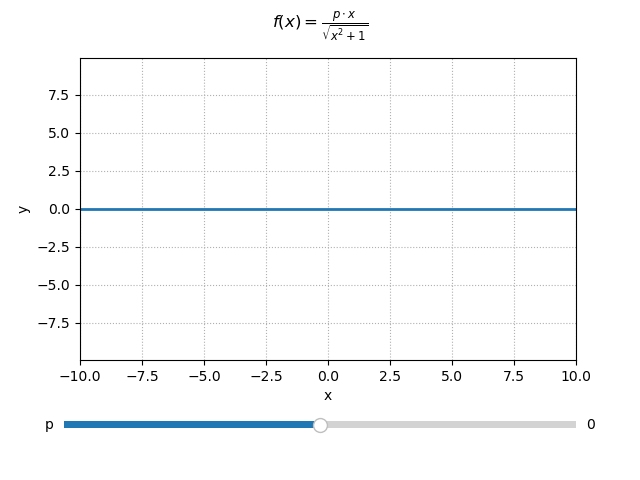

In [1]:
# IPython magic command for enabling interactive matplotlib plots in Jupyter
# notebook (disable when executing this code with a regular Python
# interpreter).
%matplotlib widget

# Imports
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Slider
import matplotlib.pyplot as plt
import numpy as np

# Parameter `x` has a static range
x = np.linspace(-10, 10, 1000)

# Parameter `p` is taken from slider with limits as defined here
p_init = 0
p_min = -10
p_max = 10

# Range of `y` values for function `f` is calculated from `x` and `p` parameters
def y_func(p):
    return p * x / np.sqrt(x ** 2 + 1)

# Latex string representation of `y_func`
y_str = "$f(x) = \\frac{p \\cdot x}{\\sqrt{x^2 + 1}}$"

# Find limits for `y`
y_range_1 = y_func(p_min)
y_range_2 = y_func(p_max)
y_min = min(min(y_range_1), min(y_range_2))
y_max = max(max(y_range_1), max(y_range_2))

# Set axes limits
xlim = (min(x), max(x))
ylim = (y_min, y_max)

# Initialize figure with axes
fig = plt.figure()
axes = plt.axes(
    xlim=xlim,
    ylim=ylim,
)
axes.grid(linestyle="dotted")
axes.set_xlabel("x")
axes.set_ylabel("y")

# Print equation of plotted function above axes
fig.suptitle(y_str)

# Expand figure window to make room for slider
fig.subplots_adjust(bottom=0.25)

# Add slider for parameter `p`
slider_axes = fig.add_axes([0.1, 0.1, 0.8, 0.03])
slider = Slider(
    ax=slider_axes,
    label='p',
    valmin=p_min,
    valmax=p_max,
    valinit=p_init,
)

# Initialize function line
line, = axes.plot(x, y_func(p_init), lw = 2) 

# Function for redrawing plot for new `p` value
def update(p):
    y = y_func(p)
    line.set_ydata(y)
    fig.canvas.draw_idle()

# Link slider to plot update function
slider.on_changed(update)

# Show plot
plt.show()